# SCOPE ξ(r) Convergence — §5.6 Runtime Scaling & §5.7 Limitations

In [1]:
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path('../../../../src').resolve()))
from config import get_snapshot_redshift

try:
    from utils.matplotlib_config import setconfig
    setconfig()
except ImportError:
    pass

In [2]:
DATA_ROOT = Path('../../../../data/2pcf/scope_xi')
MODEL     = 'lc16'
SIM       = 'L800'
N_REF     = 1024   # full-box Corrfunc reference (pending — falls back to max available n)

# Quick-look config (sections 1–2)
QK_IZ        = 155
QK_MSTAR_TAG = 'mstar9.0'
QK_Z         = get_snapshot_redshift(f'iz{QK_IZ}', 'L800')

# n values to show in detail and headline plots
PLOT_N     = [2,4,8,16,32,64, 128, 256]#[2, 8, 32, 128, 256]
HEADLINE_N = [2,4,8,16,32,64, 128, 256]#[4, 16, 64, 256]
# n=128 and n=256 are infeasible for mstar_none: runtime >> cosma8 8h/16h limits
PLOT_N_MSTAR_NONE = [n for n in PLOT_N if n < 128]

print(f'Data root:   {DATA_ROOT}')
print(f'Quick-look:  iz{QK_IZ}  →  z = {QK_Z:.3f}  ({QK_MSTAR_TAG})')

Data root:   ../../data/2pcf/scope_xi
Quick-look:  iz155  →  z = 1.496  (mstar9.0)


## 5.6 Runtime Scaling

SCOPE is implemented in Rust with Rayon-based data-parallelism, with the thread count set via `RAYON_NUM_THREADS`. The dominant cost is the pair-counting step, which scales as $N_D^2/N_{\rm threads}$ for a brute-force counter and $\mathcal{O}(N_D \log N_D / N_{\rm threads})$ with cell-list acceleration. The timing campaign (`submit_scope_xi_timing.sh`) measures wall-clock pair-counting time for L800/lc16 over a range of thread counts at fixed $N_{\rm subvol}=32$, and for different simulation boxes at 32 threads.

The left panel shows thread scaling for L800/lc16 iz155 $M_* > 9.0$. The right panel shows the dependence on box size (galaxy number) at 32 threads, with one point per simulation.

*Timing data pending: re-run `submit_scope_xi_timing.sh` on cosma5 and revisit this cell once the jobs complete. The cell degrades gracefully — if no timing CSVs are present it prints a diagnostic message and exits.*


Loaded 8 timing rows from 8 files
  sim model  iz  n_subvol  n_threads  box_mpc_h  n_gal  t_io_s  t_pairs_s  t_total_s
 L800  lc16 155        32          1     542.16 116542   1.866     89.532     91.430
 L800  lc16 155        32         16     542.16 116542   1.864      6.356      8.249
 L800  lc16 155        32          2     542.16 116542   1.874     47.279     49.184
 L800  lc16 155        32         32     542.16 116542 197.573      3.437    201.647
 L800  lc16 155        32          4     542.16 116542   1.871     24.016     25.918
 L800  lc16 155        32         64     542.16 116542 224.979      2.814    228.365
 L800  lc16 155        32          8     542.16 116542   1.872     11.587     13.491
Mill2  lc16  40        64         32      73.00  26489   9.453      0.223      9.716


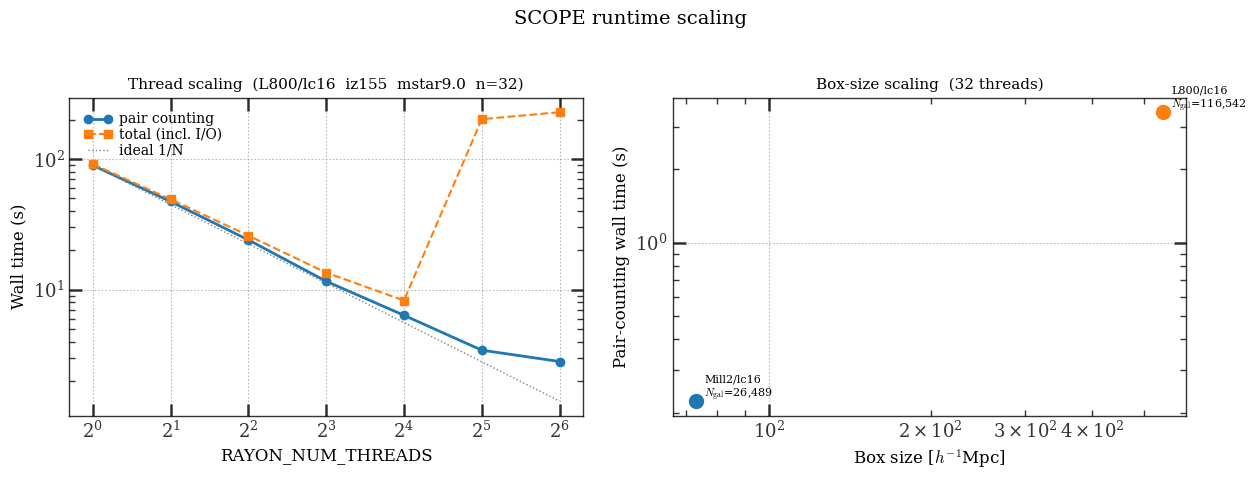

In [28]:
def plot_timing_paper():
    path = Path('../../../../data/2pcf/scope_xi_timing')
    files = sorted(path.glob('timing_*.csv'))
    if not files:
        print(f'No timing CSVs in {path}')
        return

    tdf = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    print(f'Loaded {len(tdf)} timing rows from {len(files)} files')
    print(tdf[['sim', 'model', 'iz', 'n_subvol', 'n_threads',
                'box_mpc_h', 'n_gal', 't_io_s', 't_pairs_s', 't_total_s']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Thread scaling: L800, n=32
    thread_df = (tdf[(tdf['sim'] == 'L800') & (tdf['n_subvol'] == 32)]
                   .sort_values('n_threads'))
    if not thread_df.empty:
        axes[0].plot(thread_df['n_threads'], thread_df['t_pairs_s'],
                     'o-', lw=2, label='pair counting')
        axes[0].plot(thread_df['n_threads'], thread_df['t_total_s'],
                     's--', lw=1.5, label='total (incl. I/O)')
        t1  = thread_df.loc[thread_df['n_threads'].idxmin(), 't_pairs_s']
        ts  = thread_df['n_threads'].values
        axes[0].plot(ts, t1 / ts, color='grey', lw=1, ls=':', label='ideal 1/N')
    axes[0].set_xscale('log', base=2)
    axes[0].set_yscale('log')
    axes[0].set_xlabel('RAYON_NUM_THREADS', fontsize=12)
    axes[0].set_ylabel('Wall time (s)', fontsize=12)
    axes[0].set_title('Thread scaling  (L800/lc16  iz155  mstar9.0  n=32)', fontsize=11)
    axes[0].legend(fontsize=10)

    # Box-size scaling: one point per (sim, n_threads=32)
    box_df = tdf[tdf['n_threads'] == 32].sort_values('box_mpc_h')
    if not box_df.empty:
        for _, row in box_df.iterrows():
            axes[1].scatter(row['box_mpc_h'], row['t_pairs_s'], s=100, zorder=3)
            axes[1].annotate(
                f"{row['sim']}/{row['model']}\n$N_{{\\rm gal}}$={row['n_gal']:,.0f}",
                (row['box_mpc_h'], row['t_pairs_s']),
                textcoords='offset points', xytext=(6, 3), fontsize=8,
            )
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_xlabel(r'Box size [$h^{-1}$Mpc]', fontsize=12)
    axes[1].set_ylabel('Pair-counting wall time (s)', fontsize=12)
    axes[1].set_title('Box-size scaling  (32 threads)', fontsize=11)

    fig.suptitle('SCOPE runtime scaling', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_timing_paper()


## 5.7 Limitations, Sensitivity and Threats to Validity

The results in §5.1–5.5 rest on several assumptions that must hold for the correction to be valid.

**Periodic boundary conditions.** The pair-count correction in equation (10) is derived for a periodic cubic simulation box, in which $RR_{\rm per}(r)$ is evaluated analytically from the shell geometry. Applying SCOPE to a survey-geometry catalogue with a non-trivial mask or radial selection function would require a reformulation: the random counts can no longer be computed analytically, and the sub-volume labels carry different statistical weight at different positions. The current implementation is restricted to periodic-box catalogues.

**Statistical independence of sub-volumes.** The correction treats the $k=1024$ sub-volume realisations as independent draws. In the L800 simulation, all realisations are extracted from the same parent P-Millennium $N$-body run, so large-scale density modes are shared between realisations. The bias is well corrected at all scales tested here, but the $1/\sqrt{N}$ variance scaling at two-halo scales ($r > 10\,h^{-1}$Mpc) converges more slowly than at one-halo scales (§5.5, Plot 1), which may in part reflect this large-scale correlation.

**Full-box reference noise.** The accuracy metric $|\Delta\log_{10}\xi|$ is measured against the Corrfunc full-box run, which is itself subject to cosmic variance from a single box realisation. For $\xi \gg 1$ (one-halo regime) this is negligible, but at $r \gtrsim 30\,h^{-1}$Mpc the reference uncertainty is comparable to the SCOPE residuals, limiting the precision with which the large-scale convergence threshold can be determined from a single box.

**Small-$N$ regime.** At $N_{\rm subvol} = 1$, $\alpha = \beta = 1$ and the corrected estimator reduces to the naïve estimator; the correction is only meaningful for $N \geq 2$, and the factor $m-1$ in the $\beta$ denominator diverges at $N=1$. For $N < 4$ the bias can reach several percent and the variance is large, so very small sub-volume counts are not recommended for precision work.

**Galaxy formation model scope.** The correction has been validated on `lc16` and `gp14`. Galaxy formation models with qualitatively different HOD structures — for example, models with a sharp AGN quenching scale producing an unusually deep gap between the one-halo and two-halo terms — may require re-validation, though the theoretical model-independence of $\alpha$ and $\beta$ (§3.5) suggests broad applicability.
